In [1]:
import torch
from torch import Tensor, nn
import torch.nn.functional as F
from torch.distributions.categorical import Categorical
import einops
from einops import einsum

import numpy
import random
import matplotlib.pyplot as plt
import plotly.express as px

from tqdm.auto import tqdm
from pprint import pprint
from collections import defaultdict
from dataclasses import dataclass
from typing import Any, Callable, Literal, TypeAlias
from jaxtyping import Float, Int

from plot_support import plot_feature_vectors, plot_interference_matrices

In [2]:
def linear_lr(step, steps):
    return 1-(step/steps)

def constant_lr(*_):
    return 1.0

def cosine_decay_lr(step, steps):
    return np.cos((0.5*np.pi*step) / (step-1))

In [3]:
@dataclass
class ToyModelConfig:
    n_inst: int
    n_features: int=5
    d_hidden: int=2
    n_correlated_pairs: int=0
    n_anticorrelated_pairs: int=0
    feat_mag_distn: Literal["unif", "normal"]="unif"

@dataclass
class ToySAEConfig:
    n_inst: int
    d_in: int
    d_sae: int
    sparsity_coeff: float = 0.2
    weight_normalize_eps: float = 1e-8
    tied_weights: bool = False
    ste_epsilon: float = 0.01

In [4]:
class ToyModel(nn.Module):
    """
    linear map for a single instance:
        h = W @ x
        x' = ReLU(W.T @ h + b_final)
    """
    W: Float[Tensor, "n_inst d_hidden n_features"]
    b_final: Float[Tensor, "n_inst n_features"]

    def __init__(self,
                 cfg: ToyModelConfig,
                 feature_probability: float|Tensor=0.01,
                 importance: float|Tensor=1.0,
                 device="cuda",
                ):
        super(ToyModel, self).__init__()
        self.cfg = cfg

        if isinstance(feature_probability, float):
            feature_probability = torch.tensor(feature_probability)
        self.feature_probability = feature_probability.to(device).broadcast_to((cfg.n_inst, cfg.n_features))

        if isinstance(importance, float):
            importance = torch.tensor(importance)
        self.importance = importance.to(device).broadcast_to((cfg.n_inst, cfg.n_features))

        self.W = nn.Parameter(
            nn.init.xavier_normal_(torch.empty((cfg.n_inst, cfg.n_features, cfg.d_hidden)))
        )
        self.b_final = nn.Parameter(
            torch.zeros((cfg.n_inst, cfg.n_features))
        )
        self.device = device
        self.to(device)

    
    def forward(
        self,
        features: Float[Tensor, "... n_inst n_features"],
    ) -> Float[Tensor, "... n_inst n_features"]:

        enc = einsum(
            features,
            self.W,
            "... n_inst n_features, n_inst n_features d_hidden -> ... n_inst d_hidden",
        )
        dec = einsum(
            enc,
            self.W,
            "... n_inst d_hidden, n_inst n_features d_hidden -> ... n_inst n_features",
        )
        out = F.relu(dec + self.b_final)

        return out

    
    def generate_batch(
        self,
        batch_size: int=32,
    ) -> Float[Tensor, "batch n_inst n_features"]:

        batch_shape = (batch_size, self.cfg.n_inst, self.cfg.n_features)
        feature_mag = torch.rand(batch_shape, device=self.device)
        # feature_prob = torch.rand(batch_size, device=self.device)
        feature_prob = torch.rand(batch_size, self.cfg.n_inst, self.cfg.n_features, device=self.device)

        return torch.where(feature_prob <= self.feature_probability, feature_mag, 0.0)

    
    def calculate_loss(
        self,
        out: Float[Tensor, "batch n_inst n_features"],
        batch: Float[Tensor, "batch n_inst n_features"],
    ) -> Float[Tensor, ""]:
        
        error = self.importance * ((batch - out) ** 2)
        loss = einops.reduce(error, "batch n_inst n_features -> n_inst", "mean").sum()
        
        return loss

    def optimize(
        self,
        batch_size: int=1024,
        steps: int=5000,
        log_freq: int=50,
        lr: float=1e-3,
        lr_scale: Callable[[int, int], float]=constant_lr,
    ):
        optimizer = torch.optim.Adam(self.parameters(), lr=lr)
        progress_bar = tqdm(range(steps))
        
        for step in progress_bar:
            step_lr = lr*lr_scale(step, steps)
            for group in optimizer.param_groups:
                group["lr"] = step_lr

            optimizer.zero_grad()
            batch = self.generate_batch(batch_size)
            out = self(batch)
            loss = self.calculate_loss(out, batch)
            loss.backward()
            optimizer.step()

            if step % log_freq == 0 or (step + 1 == steps):
                progress_bar.set_postfix(loss=loss.item() / self.cfg.n_inst, lr=step_lr)


In [15]:
class ToySAE(nn.Module):
    W_enc: Float[Tensor, "inst d_in d_sae"]
    _W_dec: Float[Tensor, "inst d_sae d_in"] | None
    b_enc: Float[Tensor, "inst d_sae"]
    b_dec: Float[Tensor, "inst d_in"]

    def __init__(self, cfg: ToySAEConfig, model: ToyModel) -> None:
        super(ToySAE, self).__init__()

        assert cfg.d_in == model.cfg.d_hidden, "Model's hidden dim doesn't match SAE input dim"
        self.cfg = cfg
        self.model = model.requires_grad_(False)
        self.model.W.data[1:] = self.model.W.data[0]
        self.model.b_final.data[1:] = self.model.b_final.data[0]

        self.W_enc = nn.Parameter(
            nn.init.xavier_normal_(torch.empty((cfg.n_inst, cfg.d_in, cfg.d_sae)))
        )    
        self._W_dec = nn.Parameter(
            nn.init.xavier_normal_(torch.empty((cfg.n_inst, cfg.d_sae, cfg.d_in)))
        )
        if self.cfg.tied_weights:
            self._W_dec = None

        self.b_enc = nn.Parameter(torch.zeros((cfg.n_inst, cfg.d_sae)))
        self.b_dec = nn.Parameter(torch.zeros((cfg.n_inst, cfg.d_in)))

        self.to("cuda")

    @property
    def W_dec(self) -> Float[Tensor, "n_inst d_sae d_in"]:
        return self._W_dec if self._W_dec is not None else self.W_enc.transpose(-1, -2)

    @property
    def W_dec_normalized(self) -> Float[Tensor, "inst d_sae d_in"]:
        """
        Returns decoder weights, normalized over the autoencoder input dimension.
        """
        return self.W_dec / (self.W_dec.norm(dim=-1, keepdim=True) + self.cfg.weight_normalize_eps)

    def generate_batch(self, batch_size: int) -> Float[Tensor, "batch n_inst d_in"]:
        """
        Generates a batch of hidden activations from our model.
        """
        return einsum(
            self.model.generate_batch(batch_size),
            self.model.W,
            "batch n_inst n_features, n_inst n_features d_in -> batch n_inst d_in",
        )

    def forward(
        self, h: Float[Tensor, "batch inst d_in"]
    ) -> tuple[
        dict[str, Float[Tensor, "batch inst"]],
        Float[Tensor, "batch inst"],
        Float[Tensor, "batch inst d_sae"],
        Float[Tensor, "batch inst d_in"],
    ]:

        z = F.relu(einsum(
                h - self.b_dec,
                self.W_enc,
                "batch n_inst d_in, n_inst d_in d_sae -> batch n_inst d_sae",
            ) + self.b_enc)
        
        h_recon = einsum(
                z,
                self.W_dec,
                "batch n_inst d_sae, n_inst d_sae d_in -> batch n_inst d_in",
            )
        h_recon += self.b_dec 

        L_recon = (h_recon - h).pow(2).mean(-1)
        L_sprty = z.abs().sum(-1)
        
        loss_dict = {"L_reconstruction": L_recon, "L_sparsity": L_sprty}
        loss = L_recon + self.cfg.sparsity_coeff * L_sprty
        
        return loss_dict, loss, z, h_recon

    def optimize(
        self,
        batch_size: int = 1024,
        steps: int = 10_000,
        log_freq: int = 100,
        lr: float = 1e-3,
        lr_scale: Callable[[int, int], float] = constant_lr,
        resample_method: Literal["simple", "advanced", None] = None,
        resample_freq: int = 2500,
        resample_window: int = 500,
        resample_scale: float = 0.5,
        hidden_sample_size: int = 256,
    ) -> list[dict[str, Any]]:

        assert resample_window <= resample_freq

        optimizer = torch.optim.Adam(self.parameters(), lr=lr)  # betas=(0.0, 0.999)
        frac_active_list = []
        progress_bar = tqdm(range(steps))

        # Create lists of dicts to store data we'll eventually be plotting
        data_log = []

        for step in progress_bar:
            # Resample dead latents
            if (resample_method is not None) and ((step + 1) % resample_freq == 0):
                frac_active_in_window = torch.stack(frac_active_list[-resample_window:], dim=0)
                if resample_method == "simple":
                    self.resample_simple(frac_active_in_window, resample_scale)
                elif resample_method == "advanced":
                    self.resample_advanced(frac_active_in_window, resample_scale, batch_size)

            # Update learning rate
            step_lr = lr * lr_scale(step, steps)
            for group in optimizer.param_groups:
                group["lr"] = step_lr

            # Get a batch of hidden activations from the model
            with torch.inference_mode():
                h = self.generate_batch(batch_size)

            # Optimize
            loss_dict, loss, acts, _ = self.forward(h)
            loss.mean(0).sum().backward()
            optimizer.step()
            optimizer.zero_grad()

            # Normalize decoder weights by modifying them directly (if not using tied weights)
            if not self.cfg.tied_weights:
                self.W_dec.data = self.W_dec_normalized.data

            # Calculate the mean sparsities over batch dim for each feature
            frac_active = (acts.abs() > 1e-8).float().mean(0)
            frac_active_list.append(frac_active)

            # Display progress bar, and log a bunch of values for creating plots / animations
            if step % log_freq == 0 or (step + 1 == steps):
                progress_bar.set_postfix(
                    lr=step_lr,
                    loss=loss.mean(0).sum().item(),
                    frac_active=frac_active.mean().item(),
                    **{k: v.mean(0).sum().item() for k, v in loss_dict.items()},  # type: ignore
                )
                with torch.inference_mode():
                    loss_dict, loss, acts, h_r = self.forward(
                        h := self.generate_batch(hidden_sample_size)
                    )
                data_log.append(
                    {
                        "steps": step,
                        "frac_active": (acts.abs() > 1e-8).float().mean(0).detach().cpu(),
                        "loss": loss.detach().cpu(),
                        "h": h.detach().cpu(),
                        "h_r": h_r.detach().cpu(),
                        **{name: param.detach().cpu() for name, param in self.named_parameters()},
                        **{name: loss_term.detach().cpu() for name, loss_term in loss_dict.items()},
                    }
                )

        return data_log

    @torch.no_grad()
    def resample_simple(
        self,
        frac_active_in_window: Float[Tensor, "window inst d_sae"],
        resample_scale: float,
    ) -> None:
        """
        Resamples dead latents, by modifying the model's weights and biases inplace.

        Resampling method is:
            - For each dead neuron, generate a random vector of size (d_in,), and normalize these vecs
            - Set new values of W_dec and W_enc to be these normalized vecs, at each dead neuron
            - Set b_enc to be zero, at each dead neuron
        """
        raise NotImplementedError()

    @torch.no_grad()
    def resample_advanced(
        self,
        frac_active_in_window: Float[Tensor, "window inst d_sae"],
        resample_scale: float,
        batch_size: int,
    ) -> None:
        """
        Resamples latents that have been dead for `dead_feature_window` steps, according to `frac_active`.

        Resampling method is:
            - Compute the L2 reconstruction loss produced from the hidden state vecs `h`
            - Randomly choose values of `h` with probability proportional to their reconstruction loss
            - Set new values of W_dec & W_enc to be these centered & normalized vecs, at each dead neuron
            - Set b_enc to be zero, at each dead neuron
        """
        raise NotImplementedError()

In [16]:
d_hidden = d_in = 2
n_features = d_sae = 5
n_inst = 16

cfg = ToyModelConfig(n_inst=n_inst, n_features=n_features, d_hidden=d_hidden)
model = ToyModel(cfg=cfg, device="cuda", feature_probability=0.025)
model.optimize()

  0%|          | 0/5000 [00:00<?, ?it/s]

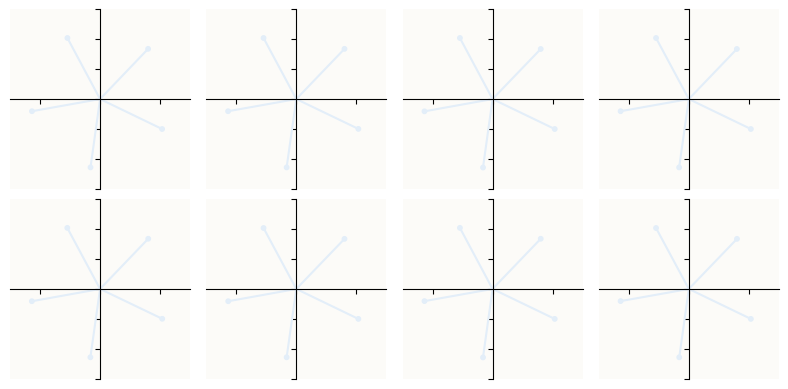

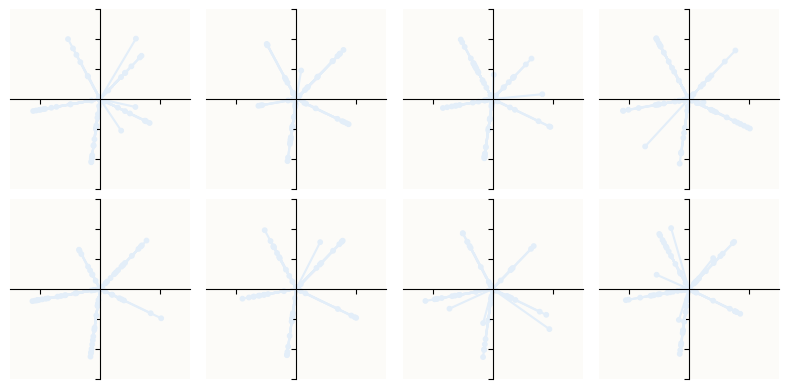

In [19]:
plot_feature_vectors(
    model.W[:8].detach().cpu(),
)

# Hidden state representation of a random batch
h = sae.generate_batch(512)  # (batch, n_inst, d_in=2)

# Rearrange to match expected input [n_instances, n_vectors, 2]
h_proj = einops.rearrange(h[:, :8], "batch inst d_in -> inst d_in batch")
h_proj = h_proj.transpose(-1, -2)  # -> (8, batch, 2)

plot_feature_vectors(
    h_proj.detach().cpu(),
)

In [17]:
sae = ToySAE(cfg=ToySAEConfig(n_inst=n_inst, d_in=d_in, d_sae=d_sae), model=model)
h = sae.generate_batch(512)

data_log = sae.optimize(steps=20_000)

utils.animate_features_in_2d(
    data_log,
    instances=list(range(8)),  # only plot the first 8 instances
    rows=["W_enc", "_W_dec"],
    filename=str(section_dir / "animation-training.html"),
    title="SAE on toy model",
)

  0%|          | 0/20000 [00:00<?, ?it/s]

NameError: name 'utils' is not defined